# ECG Sliding Window Classification

Notebook này tập trung vào pipeline phân loại ECG theo cửa sổ trượt

## Nội dung
1. Setup & Libraries
2. Data Split theo record cố định
3. Label definitions & Load ECG từ MIT-BIH
4. Preprocessing + Feature Engineering
5. Build Sliding Window Dataset
6. Training & Evaluation (RF, ET, XGB, Soft Voting)
7. So sánh cấu hình 4.5s vs 9s
8. EDA & Visualization kết quả
9. Confusion Matrix & nhận xét cuối



In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import wfdb
import neurokit2 as nk

from tqdm import tqdm
from collections import Counter

from scipy.signal import butter, filtfilt, welch, iirnotch
from scipy.stats import skew, kurtosis

from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from imblearn.over_sampling import SMOTE
import torch
import joblib
import os
from pathlib import Path

## 1. Setup & Libraries

Phần này import tất cả các thư viện cần thiết cho pipeline:
- **Data processing**: numpy, pandas, scipy
- **Signal processing**: wfdb (MIT-BIH), neurokit2 (ECG analysis)
- **Machine learning**: scikit-learn, xgboost, imblearn
- **Visualization**: matplotlib, seaborn
- **Utilities**: tqdm (progress bar), joblib (caching), pathlib

In [3]:
# Test: 102-106 (5 records)
# Val: 200, 208, 232, 233, 234 (5 records)
# Train: remaining records

all_records = [
    "100","101","102","103","105","106","107","108","109",
    "111","112","113","114","115","116","117","118","119",
    "121","122","123","124",
    "200","201","202","203","205","207","208","209","210",
    "212","213","214","215","217","219","220","221","222",
    "223","228","230","231","232","233","234"
]

test_records = ["102", "103", "104", "105", "106"]
val_records = ["200", "208", "232", "233", "234"]

# Train: remaining records
train_records = [r for r in all_records if r not in test_records and r not in val_records]

print("="*70)
print("DATA SPLIT: Custom Test/Val/Train")
print("="*70)
print(f"Total records: {len(all_records)}")
print(f"Train records ({len(train_records)}): {sorted(train_records)}")
print(f"Val records   ({len(val_records)}): {sorted(val_records)}")
print(f"Test records  ({len(test_records)}): {sorted(test_records)}")
print(f"Overlap check: {set(train_records) & set(val_records) & set(test_records)}")
print("="*70)

DATA SPLIT: Custom Test/Val/Train
Total records: 47
Train records (38): ['100', '101', '107', '108', '109', '111', '112', '113', '114', '115', '116', '117', '118', '119', '121', '122', '123', '124', '201', '202', '203', '205', '207', '209', '210', '212', '213', '214', '215', '217', '219', '220', '221', '222', '223', '228', '230', '231']
Val records   (5): ['200', '208', '232', '233', '234']
Test records  (5): ['102', '103', '104', '105', '106']
Overlap check: set()


## 2. Data Split by Records

Phần này thiết lập tập `train/validation/test` theo danh sách record cố định để đảm bảo:
- Tái lập kết quả
- Không có overlap giữa các tập
- Đánh giá khách quan trên test set

In [4]:
# Label definitions for ECG beat classification
NORMAL_SYMBOLS = {"N"}  # Normal beat only
DROP_SYMBOLS = {"+", "x", '"', "Q", "~"}  # Rhythm change, non-conducted P-wave, comment, unclassifiable, signal quality
ABNORMAL_SYMBOLS = {"V", "A", "L", "R", "!", "J", "S", "E", "F"}  # Abnormal beats

def load_mitbih_record(record_id):
    record = wfdb.rdrecord(record_id, pn_dir="mitdb")
    ann = wfdb.rdann(record_id, "atr", pn_dir="mitdb")

    signal_1d = record.p_signal[:, 0].astype(np.float64)   # dùng channel 0
    fs = float(record.fs)
    ann_samples = np.asarray(ann.sample)
    ann_symbols = np.asarray(ann.symbol)
    
    return signal_1d, fs, ann_samples, ann_symbols

## 3. Load ECG Data & Label Definitions

Phần này:
- Định nghĩa **nhãn lớp** theo ký hiệu AAMI của MIT-BIH:
  - `NORMAL_SYMBOLS = {"N"}`: Beat bình thường
  - `DROP_SYMBOLS`: Ký hiệu loại bỏ (không xác định được)
  - `ABNORMAL_SYMBOLS`: Beat bất thường
- Định nghĩa hàm `load_mitbih_record()` đọc tín hiệu ECG từ MIT-BIH database

In [5]:
def butter_bandpass(lowcut, highcut, fs, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype="band")
    return b, a

def apply_bandpass_filter(signal, fs, lowcut=0.5, highcut=40.0, order=4):
    b, a = butter_bandpass(lowcut, highcut, fs, order=order)
    return filtfilt(b, a, signal)

def apply_notch_filter(signal, fs, notch_freq=60.0, quality=30):
    """Remove mains noise (60Hz hoặc 50Hz)"""
    b, a = iirnotch(notch_freq, quality, fs)
    return filtfilt(b, a, signal)

def remove_baseline(signal, order=1):
    """Detrending: loại bỏ baseline drift"""
    from scipy.signal import detrend
    return detrend(signal, type='linear' if order == 1 else 'constant')

def apply_advanced_preprocessing(signal, fs):
    """Enhanced preprocessing pipeline theo recommendations"""
    from scipy.signal import medfilt
    
    # Ensure fs is a scalar
    if isinstance(fs, (list, tuple)):
        fs = fs[0] if fs else 360.0
    fs = float(fs)
    
    # 1. Motion artifact removal (Median filter)
    signal = medfilt(signal, kernel_size=5)
    
    # 2. High-pass filter (0.3 Hz) - baseline removal
    b_hp, a_hp = butter(2, 0.3/(fs/2), btype='high')
    signal = filtfilt(b_hp, a_hp, signal)
    
    # 3. Bandpass (0.5-45 Hz) - ECG frequency band
    nyq = fs / 2.0
    freqs = np.array([0.5, 45]) / nyq
    b_bp, a_bp = butter(4, freqs, btype='band')
    signal = filtfilt(b_bp, a_bp, signal)
    
    # 4. Multi-notch filters (60, 120, 180 Hz) - power line noise
    for notch_freq in [60, 120, 180]:
        try:
            b_notch, a_notch = iirnotch(notch_freq, 30, fs)
            signal = filtfilt(b_notch, a_notch, signal)
        except:
            pass
    
    # 5. Detrending
    signal = remove_baseline(signal, order=1)
    
    return signal

def robust_normalize_1d(x, clip_std=4):
    """Robust normalization with outlier clipping"""
    x = np.asarray(x, dtype=np.float64)
    
    # Clip outliers (beyond 4 sigma using MAD)
    median = np.median(x)
    mad = np.median(np.abs(x - median))
    if mad > 0:
        x_clipped = np.clip(x, median - clip_std * mad, median + clip_std * mad)
    else:
        x_clipped = x
    
    # Robust normalization using IQR
    q25, q75 = np.percentile(x_clipped, [25, 75])
    iqr = q75 - q25
    if iqr > 0:
        return (x_clipped - q25) / iqr
    return x_clipped - q25

## 4. Signal Preprocessing Pipeline

Phần này định nghĩa hàm tiền xử lý tín hiệu ECG nâng cao:
- **Median filter** (kernel=5): Loại bỏ artifact chuyển động
- **High-pass filter** (0.3 Hz): Loại bỏ baseline drift
- **Bandpass filter** (0.5-45 Hz): Giữ tần số ECG, loại tần số không cần thiết
- **Multi-notch filters** (60, 120, 180 Hz): Loại bỏ nhiễu dòng điện
- **Detrending**: Xử lý linear baseline
- **Robust normalization** (MAD + IQR): Chuẩn hóa mạnh mẽ, không nhạy với outlier

In [6]:
def create_sliding_windows(
    signal,
    ann_samples,
    ann_symbols,
    record_id,
    window_size=300,   # window size in samples
    step_size=None     # step_size is set equal to window_size
    ):
    windows = []
    labels = []
    metadata = []

    # Use step_size = window_size
    step_size = int(window_size)
    n = len(signal)

    for start in range(0, n - window_size + 1, step_size):
        end = start + window_size
        center = start + window_size // 2
        window = signal[start:end]

        # Find annotations within window
        in_window = (ann_samples >= start) & (ann_samples < end)
        local_samples = ann_samples[in_window]
        local_symbols = ann_symbols[in_window]

        # Filter out unwanted symbols (DROP_SYMBOLS)
        valid_idx = [i for i, s in enumerate(local_symbols) if s not in DROP_SYMBOLS]
        if len(valid_idx) == 0:
            continue

        valid_samples = np.array([local_samples[i] for i in valid_idx])
        valid_symbols = np.array([local_symbols[i] for i in valid_idx])

        # Assign label based on beat nearest to window center
        nearest_idx = np.argmin(np.abs(valid_samples - center))
        center_symbol = valid_symbols[nearest_idx]

        # Label: 0 = NORMAL (only N), 1 = ABNORMAL (everything else)
        if center_symbol in NORMAL_SYMBOLS:
            label = 0
        else:
            label = 1

        windows.append(window.copy())
        labels.append(label)
        metadata.append({
            "record_id": record_id,
            "start": int(start),
            "end": int(end),
            "center_symbol": str(center_symbol),
            "label": int(label)
        })

    return windows, labels, metadata

## 5. Create Sliding Windows

Hàm `create_sliding_windows()` cắt tín hiệu ECG thành các cửa sổ trượt:
- **Input**: Tín hiệu đã xử lý, vị trí beat (ann_samples), ký hiệu beat (ann_symbols)
- **Quá trình**:
  1. Chia tín hiệu với window_size và step_size (bằng window_size)
  2. Tìm beat trong từng cửa sổ, loại bỏ beat không mong muốn
  3. Gán nhãn dựa trên beat gần tâm cửa sổ nhất
- **Output**: Danh sách cửa sổ, nhãn tương ứng, metadata (record_id, vị trí, ký hiệu)

In [7]:
def _safe_iqr(x):
    q25, q75 = np.percentile(x, [25, 75])
    return float(q75 - q25)

def _safe_rms(x):
    return float(np.sqrt(np.mean(np.square(x))))

def _frame_level_features(x, prefix=""):
    x = np.asarray(x, dtype=np.float64)
    d1 = np.diff(x)
    d2 = np.diff(x, n=2)
    return {
        f"{prefix}mean": float(np.mean(x)),
        f"{prefix}std": float(np.std(x)),
        f"{prefix}min": float(np.min(x)),
        f"{prefix}max": float(np.max(x)),
        f"{prefix}iqr": _safe_iqr(x),
        f"{prefix}rms": _safe_rms(x),
        f"{prefix}absolute_sum_of_changes": float(np.sum(np.abs(d1))) if len(d1) > 0 else 0.0,
        f"{prefix}mean_abs_change": float(np.mean(np.abs(d1))) if len(d1) > 0 else 0.0,
        f"{prefix}line_length": float(np.sum(np.abs(d1))) if len(d1) > 0 else 0.0,
        f"{prefix}second_derivative": float(np.mean(np.abs(d2))) if len(d2) > 0 else 0.0,
        f"{prefix}skewness": float(skew(x)) if np.std(x) > 1e-10 else 0.0,
        f"{prefix}kurtosis": float(kurtosis(x)) if np.std(x) > 1e-10 else 0.0,
        f"{prefix}peak_to_peak_amplitude": float(np.ptp(x)),
    }

def _window_rr_hr_features(x, fs=360.0, include_rmssd=False):
    x = np.asarray(x, dtype=np.float64)
    out = {
        "beat_count": 0.0,
        "mean_RR": 0.0,
        "median_RR": 0.0,
        "RR_range": 0.0,
        "normalized_RR_mean": 0.0,
        "normalized_RR_std": 0.0,
        "mean_HR": 0.0,
        "HR_range": 0.0,
    }
    if include_rmssd:
        out["RMSSD"] = 0.0

    try:
        cleaned = nk.ecg_clean(x, sampling_rate=fs, method="neurokit")
        _, peaks_info = nk.ecg_peaks(cleaned, sampling_rate=fs)
        rpeaks = peaks_info.get("ECG_R_Peaks", np.array([]))
        rpeaks = np.asarray(rpeaks, dtype=int)
        out["beat_count"] = float(len(rpeaks))

        if len(rpeaks) >= 2:
            rr = np.diff(rpeaks) / float(fs)
            rr = rr[rr > 0]
            if len(rr) > 0:
                rr_mean = float(np.mean(rr))
                rr_std = float(np.std(rr))
                z_rr = (rr - rr_mean) / (rr_std + 1e-12)

                hr = 60.0 / rr

                out.update({
                    "mean_RR": rr_mean,
                    "median_RR": float(np.median(rr)),
                    "RR_range": float(np.max(rr) - np.min(rr)),
                    "normalized_RR_mean": float(np.mean(z_rr)),
                    "normalized_RR_std": float(np.std(z_rr)),
                    "mean_HR": float(np.mean(hr)),
                    "HR_range": float(np.max(hr) - np.min(hr)),
                })

                if include_rmssd and len(rr) >= 2:
                    out["RMSSD"] = float(np.sqrt(np.mean(np.diff(rr) ** 2)))
    except Exception:
        pass

    return out

def extract_features_1d(x, fs=360.0, frame_seconds=0.75, num_frames=6, window_seconds=4.5):
    """NeuroKit2-based feature extraction with frame-level + window-level features."""
    x = np.asarray(x, dtype=np.float64)
    frame_len = max(1, int(round(frame_seconds * fs)))

    features = {}

    # Frame-level features: split into 6 frames of 0.75s
    for i in range(num_frames):
        start = i * frame_len
        end = start + frame_len
        if end <= len(x):
            frame = x[start:end]
            features.update(_frame_level_features(frame, prefix=f"f{i+1}_"))
        else:
            # zero-fill features for missing frame
            features.update({
                f"f{i+1}_mean": 0.0,
                f"f{i+1}_std": 0.0,
                f"f{i+1}_min": 0.0,
                f"f{i+1}_max": 0.0,
                f"f{i+1}_iqr": 0.0,
                f"f{i+1}_rms": 0.0,
                f"f{i+1}_absolute_sum_of_changes": 0.0,
                f"f{i+1}_mean_abs_change": 0.0,
                f"f{i+1}_line_length": 0.0,
                f"f{i+1}_second_derivative": 0.0,
                f"f{i+1}_skewness": 0.0,
                f"f{i+1}_kurtosis": 0.0,
                f"f{i+1}_peak_to_peak_amplitude": 0.0,
            })

    # Window-level RR/HR features
    include_rmssd = bool(window_seconds >= 9.0)
    features.update(_window_rr_hr_features(x, fs=fs, include_rmssd=include_rmssd))

    return features

def compute_feature_matrix(windows, fs=360.0, frame_seconds=0.75, num_frames=6, window_seconds=4.5):
    rows = [
        extract_features_1d(
            w,
            fs=fs,
            frame_seconds=frame_seconds,
            num_frames=num_frames,
            window_seconds=window_seconds,
        )
        for w in windows
    ]
    return pd.DataFrame(rows).fillna(0.0)

## 6. Feature Extraction Functions

Phần này định nghĩa 3 loại hàm trích xuất đặc trưng:

### 6a. Frame-level Features (_frame_level_features)
Chia cửa sổ thành 6 frame (0.75s/frame) và tính 13 đặc trưng cho mỗi frame:
- Thống kê cơ bản: mean, std, min, max, iqr, rms
- Đặc trưng động: absolute_sum_of_changes, mean_abs_change, line_length, second_derivative
- Hình dạng: skewness, kurtosis, peak_to_peak_amplitude

### 6b. Window-level RR/HR Features (_window_rr_hr_features)
Dùng neurokit2 để phát hiện R-peak và tính:
- Beat count, mean/median RR intervals
- Heart rate (HR) statistics
- Normalized RR (z-score)
- RMSSD (chỉ với window ≥ 9s)

### 6c. Combined Window Features (extract_features_1d)
Kết hợp cả frame-level và window-level để tạo feature vector hoàn chỉnh

In [8]:

 # Build datasets with ADVANCED PREPROCESSING
def build_sliding_dataset_advanced(record_ids, window_size=300, step_size=None):
    """Build dataset with advanced preprocessing pipeline."""
    all_windows = []
    all_labels = []
    all_meta = []
    fs_ref = None

    if step_size is not None and step_size != window_size:
        print("[Info] step_size is set to window_size.")

    for rid in tqdm(record_ids, desc="Building dataset with advanced preprocessing"):
        signal, fs, ann_samples, ann_symbols = load_mitbih_record(rid)

        # Apply ADVANCED preprocessing pipeline
        signal = apply_advanced_preprocessing(signal, fs)

        windows, labels, meta = create_sliding_windows(
            signal=signal,
            ann_samples=ann_samples,
            ann_symbols=ann_symbols,
            record_id=rid,
            window_size=window_size,
            step_size=window_size
        )

        windows = [robust_normalize_1d(w) for w in windows]

        all_windows.extend(windows)
        all_labels.extend(labels)
        all_meta.extend(meta)

        if fs_ref is None:
            fs_ref = fs

    window_seconds = window_size / (fs_ref if fs_ref is not None else 360.0)
    X_df = compute_feature_matrix(
        all_windows,
        fs=fs_ref if fs_ref is not None else 360.0,
        frame_seconds=0.75,
        num_frames=6,
        window_seconds=window_seconds,
    )
    y = np.array(all_labels, dtype=int)
    meta_df = pd.DataFrame(all_meta)

    return X_df, y, meta_df, all_windows

print("✓ Advanced preprocessing function defined")
print("✓ Feature extraction uses neurokit2")


✓ Advanced preprocessing function defined
✓ Feature extraction uses neurokit2


## 7. Build Dataset with Advanced Preprocessing

Hàm `build_sliding_dataset_advanced()` xây dựng dataset hoàn chỉnh:
- **Xử lý từng record**: Load, preprocess nâng cao, tạo sliding windows
- **Chuẩn hóa robust**: Loại bỏ outlier trước khi dựng feature
- **Feature matrix**: Tính toán đặc trưng cho từng cửa sổ
- **Output**: Feature DataFrame (X), nhãn (y), metadata, raw windows
- **Lưu ý**: Window size có thể là 1620 (4.5s @ 360Hz) hoặc 3240 (9s @ 360Hz)

In [9]:

print("\n" + "="*70)
print("BUILDING DATASETS WITH ADVANCED PREPROCESSING")
print("="*70)

# Build TRAIN dataset (4.5s)
print("\nBuilding TRAIN dataset (4.5s)...")
X_train_adv, y_train_adv, meta_train_adv, raw_train_adv = build_sliding_dataset_advanced(
    train_records, window_size=1620
 )
print(f"Train: {len(y_train_adv)} windows, shape {X_train_adv.shape}")
print(f"Train distribution: {Counter(y_train_adv)}")

# Build VAL dataset (4.5s)
print("\nBuilding VAL dataset (4.5s)...")
X_val_adv, y_val_adv, meta_val_adv, raw_val_adv = build_sliding_dataset_advanced(
    val_records, window_size=1620
 )
print(f"Val: {len(y_val_adv)} windows, shape {X_val_adv.shape}")
print(f"Val distribution: {Counter(y_val_adv)}")

# Build TEST dataset (4.5s)
print("\nBuilding TEST dataset (4.5s)...")
X_test_adv, y_test_adv, meta_test_adv, raw_test_adv = build_sliding_dataset_advanced(
    test_records, window_size=1620
 )
print(f"Test: {len(y_test_adv)} windows, shape {X_test_adv.shape}")
print(f"Test distribution: {Counter(y_test_adv)}")

print("\n" + "="*70)
print("✓ Datasets built successfully!")
print("="*70)



BUILDING DATASETS WITH ADVANCED PREPROCESSING

Building TRAIN dataset (4.5s)...


Building dataset with advanced preprocessing: 100%|██████████| 38/38 [13:09<00:00, 20.77s/it]


Train: 15238 windows, shape (15238, 86)
Train distribution: Counter({np.int64(0): 10766, np.int64(1): 4472})

Building VAL dataset (4.5s)...


Building dataset with advanced preprocessing: 100%|██████████| 5/5 [01:36<00:00, 19.20s/it]


Val: 2004 windows, shape (2004, 86)
Val distribution: Counter({np.int64(0): 1188, np.int64(1): 816})

Building TEST dataset (4.5s)...


Building dataset with advanced preprocessing: 100%|██████████| 5/5 [01:41<00:00, 20.20s/it]


Test: 2004 windows, shape (2004, 86)
Test distribution: Counter({np.int64(0): 1150, np.int64(1): 854})

✓ Datasets built successfully!


## 8. Build Datasets for 4.5s Window

Cell này xây dựng dataset hoàn chỉnh cho window 4.5s (1620 samples):
- Xây dựng train/val/test datasets từ các record tương ứng
- In thống kê số lượng mẫu và phân phối nhãn cho từng tập
- Lưu ý: Train set sẽ được cân bằng bằng SMOTE sau này

In [10]:
print("\n" + "="*70)
print("SETUP: DATASET CACHING & CONFIGURATION")
print("="*70)

dataset_cache_dir = Path("dataset_cache")
dataset_cache_dir.mkdir(exist_ok=True)

# Window size configurations
WINDOW_CONFIGS = {
    "4.5s": {"window_size": 1620},
    "9s": {"window_size": 3240}
}

def load_cached_datasets():
    """Load all datasets from cache if available."""
    try:
        all_exist = all((dataset_cache_dir / f"dataset_{name}.joblib").exists()
                       for name in ["4.5s", "9s"] )
        if all_exist:
            print("\nLoading cached datasets...")
            results_by_window = {}
            for name in ["4.5s", "9s"]:
                results_by_window[name] = joblib.load(dataset_cache_dir / f"dataset_{name}.joblib")
                data = results_by_window[name]
                print(f"  {name}: Train={data['X_train'].shape}, Val={data['X_val'].shape}, Test={data['X_test'].shape}")
            print("✓ All datasets loaded successfully!")
            return results_by_window
    except Exception as e:
        print(f"Cache loading failed: {e}")
    return None

results_by_window = load_cached_datasets()

if results_by_window is None:
    results_by_window = {}
    print("Initializing new results_by_window dictionary for building datasets")

print("\n✓ Setup complete. Ready to build 4.5s and 9s datasets.")


SETUP: DATASET CACHING & CONFIGURATION
Initializing new results_by_window dictionary for building datasets

✓ Setup complete. Ready to build 4.5s and 9s datasets.


## 9. Dataset Caching & Configuration

Phần này:
- Định nghĩa window configurations (4.5s: 1620 samples, 9s: 3240 samples)
- Tạo thư mục cache để lưu datasets
- Hàm `load_cached_datasets()` kiểm tra xem dataset đã được xây dựng chưa
- Tránh việc rebuild dataset từ đầu nếu đã có cached version

In [11]:
# EDA: Frame-level & Window-level features (4.5s)
import seaborn as sns

print("\n" + "="*70)
print("EDA: FRAME-LEVEL & WINDOW-LEVEL FEATURES")
print("="*70)

# Load feature table + labels from existing variables or cache
X_eda = None
y_eda = None

if "X_train_45" in globals() and "y_train_45" in globals():
    X_eda = X_train_45.copy()
    y_eda = np.asarray(y_train_45)
    print("Using in-memory 4.5s train data.")
elif "dataset_cache_dir" in globals() and (dataset_cache_dir / "dataset_4.5s.joblib").exists():
    data_eda = joblib.load(dataset_cache_dir / "dataset_4.5s.joblib")
    X_eda = data_eda["X_train"].copy()
    y_eda = np.asarray(data_eda["y_train"])
    print("Using cached 4.5s train data.")
else:
    print("No 4.5s data found yet. Run the 4.5s build cell first, then rerun this EDA cell.")

if X_eda is not None and y_eda is not None:
    eda_df = X_eda.copy()
    eda_df["class"] = y_eda
    eda_df["class_name"] = eda_df["class"].map({0: "Normal", 1: "Abnormal"})

    frame_cols = [c for c in eda_df.columns if c.startswith("f") and c != "class" and c != "class_name"]
    window_cols = [
        "beat_count", "mean_RR", "median_RR", "RR_range",
        "normalized_RR_mean", "normalized_RR_std", "mean_HR", "HR_range", "RMSSD"
    ]
    window_cols = [c for c in window_cols if c in eda_df.columns]

    # Correlation heatmap - window-level
    if len(window_cols) >= 2:
        plt.figure(figsize=(9, 7))
        corr_w = eda_df[window_cols].corr()
        sns.heatmap(corr_w, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
        plt.title("Correlation Heatmap - Window-level Features")
        plt.tight_layout()
        plt.show()

    # 5) Line plot feature by frame position
    frame_positions = np.arange(1, 7)
    metrics_for_line = ["mean", "rms", "line_length", "peak_to_peak_amplitude"]

    fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True)
    axes = axes.ravel()

    for idx, metric in enumerate(metrics_for_line):
        normal_vals = []
        abnormal_vals = []
        for p in frame_positions:
            col = f"f{p}_{metric}"
            if col in eda_df.columns:
                normal_vals.append(eda_df.loc[eda_df["class"] == 0, col].mean())
                abnormal_vals.append(eda_df.loc[eda_df["class"] == 1, col].mean())
            else:
                normal_vals.append(np.nan)
                abnormal_vals.append(np.nan)

        axes[idx].plot(frame_positions, normal_vals, marker="o", label="Normal")
        axes[idx].plot(frame_positions, abnormal_vals, marker="o", label="Abnormal")
        axes[idx].set_title(f"Feature trend across frame positions: {metric}")
        axes[idx].set_xlabel("Frame position (1..6)")
        axes[idx].set_ylabel(f"Mean {metric}")
        axes[idx].grid(alpha=0.3)
        axes[idx].legend()

    plt.tight_layout()
    plt.show()

    print("\nEDA complete.")


EDA: FRAME-LEVEL & WINDOW-LEVEL FEATURES
No 4.5s data found yet. Run the 4.5s build cell first, then rerun this EDA cell.


## 10. EDA: Feature Analysis

Cell này thực hiện phân tích khám phá đặc trưng:
- **Correlation heatmap window-level**: Xem mối quan hệ giữa đặc trưng RR/HR
- **Line plot theo frame position**: Xu hướng giá trị đặc trưng qua 6 frame của cửa sổ
- **Dữ liệu**: Dùng train set 4.5s hoặc load từ cache

In [12]:
print("\n" + "="*70)
print("FULL TEST: BUILD 4.5s + TRAIN & EVALUATE")
print("="*70)

import time
start_time_45 = time.time()

cache_file_45 = dataset_cache_dir / "dataset_4.5s.joblib"
if cache_file_45.exists():
    print("\nLoading 4.5s from cache...")
    data_45 = joblib.load(cache_file_45)
    X_train_45 = data_45["X_train"]
    y_train_45 = data_45["y_train"]
    X_val_45 = data_45["X_val"]
    y_val_45 = data_45["y_val"]
    X_test_45 = data_45["X_test"]
    y_test_45 = data_45["y_test"]
    print(f"  Train: {X_train_45.shape}, Val: {X_val_45.shape}, Test: {X_test_45.shape}")
    print("✓ Dataset loaded!")
else:
    print("\nBuilding 4.5s dataset...")
    cfg_45 = WINDOW_CONFIGS["4.5s"]

    print("  Building train dataset...")
    X_train_45, y_train_45, _, _ = build_sliding_dataset_advanced(
        train_records, window_size=cfg_45["window_size"]
    )
    print(f"    Train: {len(y_train_45)} windows, dist: {Counter(y_train_45)}")

    print("  Building val dataset...")
    X_val_45, y_val_45, _, _ = build_sliding_dataset_advanced(
        val_records, window_size=cfg_45["window_size"]
    )
    print(f"    Val:   {len(y_val_45)} windows, dist: {Counter(y_val_45)}")

    print("  Building test dataset...")
    X_test_45, y_test_45, _, _ = build_sliding_dataset_advanced(
        test_records, window_size=cfg_45["window_size"]
    )
    print(f"    Test:  {len(y_test_45)} windows, dist: {Counter(y_test_45)}")

    data_45 = {
        "X_train": X_train_45, "y_train": y_train_45,
        "X_val": X_val_45, "y_val": y_val_45,
        "X_test": X_test_45, "y_test": y_test_45
    }
    joblib.dump(data_45, cache_file_45)
    print("\nSaved to cache!")

print("\n" + "-"*70)
print("PREPROCESSING")
print("-"*70)
scaler_45 = StandardScaler()
X_train_scaled_45 = scaler_45.fit_transform(X_train_45)
X_val_scaled_45 = scaler_45.transform(X_val_45)
X_test_scaled_45 = scaler_45.transform(X_test_45)
print("✓ StandardScaler applied")

print("\nApplying SMOTE (ratio=1.0)...")
smote_45 = SMOTE(random_state=42, k_neighbors=5)
X_train_sm_45, y_train_sm_45 = smote_45.fit_resample(X_train_scaled_45, y_train_45)
print(f"  Before SMOTE: {Counter(y_train_45)}")
print(f"  After SMOTE:  {Counter(y_train_sm_45)}")

print("\nFeature selection (SelectKBest k=25)...")
selector_45 = SelectKBest(f_classif, k=min(25, X_train_sm_45.shape[1]))
X_train_sel_45 = selector_45.fit_transform(X_train_sm_45, y_train_sm_45)
X_val_sel_45 = selector_45.transform(X_val_scaled_45)
X_test_sel_45 = selector_45.transform(X_test_scaled_45)
print(f"✓ Selected {X_train_sel_45.shape[1]} features")

print("\n" + "-"*70)
print("TRAINING MODELS")
print("-"*70)
rf_45 = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1, max_depth=15)
rf_45.fit(X_train_sel_45, y_train_sm_45)
et_45 = ExtraTreesClassifier(n_estimators=200, random_state=42, n_jobs=-1, max_depth=15)
et_45.fit(X_train_sel_45, y_train_sm_45)
xgb_45 = XGBClassifier(
    n_estimators=200, max_depth=8, learning_rate=0.1,
    random_state=42, tree_method='hist', verbosity=0, n_jobs=-1
 )
xgb_45.fit(X_train_sel_45, y_train_sm_45)
voting_clf_45 = VotingClassifier(
    estimators=[('rf', rf_45), ('et', et_45), ('xgb', xgb_45)],
    weights=[0.3, 0.3, 0.4], voting='soft', n_jobs=-1
 )
voting_clf_45.fit(X_train_sel_45, y_train_sm_45)
print("✓ Ensemble trained")

best_threshold_45 = 0.5
print(f"\nThreshold fixed: {best_threshold_45:.2f}")

y_test_proba_45 = voting_clf_45.predict_proba(X_test_sel_45)[:, 1]
y_test_pred_45 = (y_test_proba_45 >= best_threshold_45).astype(int)

acc_45 = accuracy_score(y_test_45, y_test_pred_45)
prec_45 = precision_score(y_test_45, y_test_pred_45, zero_division=0)
rec_45 = recall_score(y_test_45, y_test_pred_45, zero_division=0)
f1_45 = f1_score(y_test_45, y_test_pred_45, zero_division=0)
try:
    auc_45 = roc_auc_score(y_test_45, y_test_proba_45)
except Exception:
    auc_45 = 0.0

cm_45 = confusion_matrix(y_test_45, y_test_pred_45)
tn_45, fp_45, fn_45, tp_45 = cm_45.ravel()
spec_45 = tn_45 / (tn_45 + fp_45) if (tn_45 + fp_45) > 0 else 0.0

window_size_results = {}
window_size_results["4.5s"] = {
    "accuracy": acc_45, "precision": prec_45, "recall": rec_45,
    "f1": f1_45, "auc": auc_45, "best_threshold": best_threshold_45,
    "y_pred": y_test_pred_45, "y_proba": y_test_proba_45
}

print("\nFINAL TEST SCORES (4.5s)")
print(f"  Accuracy:  {acc_45:.4f}")
print(f"  Precision: {prec_45:.4f}")
print(f"  Recall:    {rec_45:.4f}")
print(f"  F1-Score:  {f1_45:.4f}")
print(f"  AUC-ROC:   {auc_45:.4f}")
print(f"  Specificity: {spec_45:.4f}")

elapsed_45 = time.time() - start_time_45
print(f"\n✅ 4.5s TEST COMPLETE - Elapsed: {elapsed_45:.1f}s")


FULL TEST: BUILD 4.5s + TRAIN & EVALUATE

Building 4.5s dataset...
  Building train dataset...


Building dataset with advanced preprocessing:   0%|          | 0/38 [00:00<?, ?it/s]

Building dataset with advanced preprocessing: 100%|██████████| 38/38 [11:08<00:00, 17.59s/it]


    Train: 15238 windows, dist: Counter({np.int64(0): 10766, np.int64(1): 4472})
  Building val dataset...


Building dataset with advanced preprocessing: 100%|██████████| 5/5 [01:26<00:00, 17.24s/it]


    Val:   2004 windows, dist: Counter({np.int64(0): 1188, np.int64(1): 816})
  Building test dataset...


Building dataset with advanced preprocessing: 100%|██████████| 5/5 [01:27<00:00, 17.47s/it]


    Test:  2004 windows, dist: Counter({np.int64(0): 1150, np.int64(1): 854})

Saved to cache!

----------------------------------------------------------------------
PREPROCESSING
----------------------------------------------------------------------
✓ StandardScaler applied

Applying SMOTE (ratio=1.0)...
  Before SMOTE: Counter({np.int64(0): 10766, np.int64(1): 4472})
  After SMOTE:  Counter({np.int64(0): 10766, np.int64(1): 10766})

Feature selection (SelectKBest k=25)...
✓ Selected 25 features

----------------------------------------------------------------------
TRAINING MODELS
----------------------------------------------------------------------
✓ Ensemble trained

Threshold fixed: 0.50

FINAL TEST SCORES (4.5s)
  Accuracy:  0.6083
  Precision: 0.5638
  Recall:    0.3571
  F1-Score:  0.4373
  AUC-ROC:   0.7342
  Specificity: 0.7948

✅ 4.5s TEST COMPLETE - Elapsed: 1426.0s


## 11. Full Pipeline: Build 4.5s + Train & Evaluate

Pipeline hoàn chỉnh cho window 4.5s:
1. **Load/Build datasets**: Train/val/test từ cache hoặc xây dựng mới
2. **Preprocessing**: StandardScaler, SMOTE (cân bằng train), SelectKBest (25 features)
3. **Training**: RandomForest, ExtraTrees, XGBoost
4. **Ensemble**: Soft Voting (weight: RF=0.3, ET=0.3, XGB=0.4) với threshold=0.5
5. **Evaluation**: Metrics trên test set (Accuracy, Precision, Recall, F1, AUC-ROC, Specificity)


CONFUSION MATRIX: 4.5s
TN: 914, FP: 236, FN: 549, TP: 305
Sensitivity: 0.3571
Specificity: 0.7948
Saved: confusion_matrix_4.5s.png


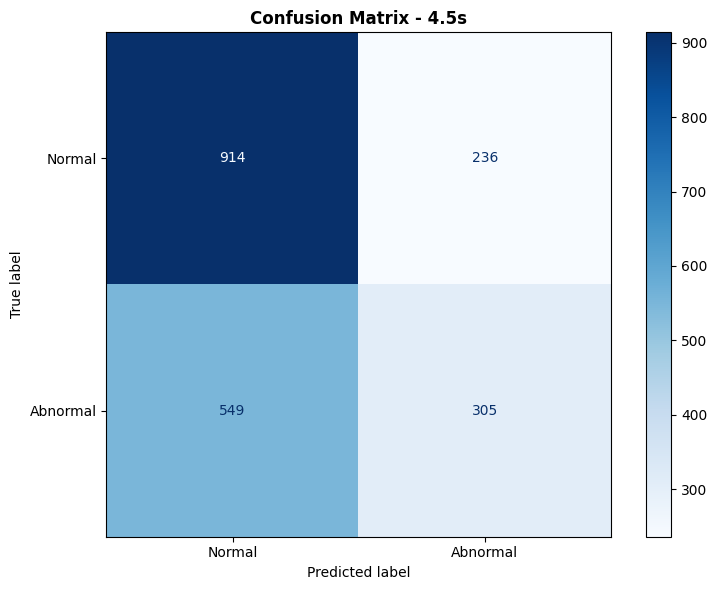

In [13]:
print("\n" + "="*70)
print("CONFUSION MATRIX: 4.5s")
print("="*70)

if "y_test_45" not in globals() or "y_test_pred_45" not in globals():
    print("Run Cell 11 first to generate y_test_45 and y_test_pred_45.")
else:
    cm_45_plot = confusion_matrix(y_test_45, y_test_pred_45)
    tn_45_plot, fp_45_plot, fn_45_plot, tp_45_plot = cm_45_plot.ravel()
    sensitivity_45 = tp_45_plot / (tp_45_plot + fn_45_plot) if (tp_45_plot + fn_45_plot) > 0 else 0.0
    specificity_45 = tn_45_plot / (tn_45_plot + fp_45_plot) if (tn_45_plot + fp_45_plot) > 0 else 0.0

    print(f"TN: {tn_45_plot}, FP: {fp_45_plot}, FN: {fn_45_plot}, TP: {tp_45_plot}")
    print(f"Sensitivity: {sensitivity_45:.4f}")
    print(f"Specificity: {specificity_45:.4f}")

    fig, ax = plt.subplots(figsize=(8, 6))
    disp_45 = ConfusionMatrixDisplay(confusion_matrix=cm_45_plot, display_labels=["Normal", "Abnormal"])
    disp_45.plot(ax=ax, cmap="Blues", values_format="d")
    ax.set_title("Confusion Matrix - 4.5s", fontweight="bold")
    plt.tight_layout()
    plt.savefig("confusion_matrix_4.5s.png", dpi=150, bbox_inches="tight")
    print("Saved: confusion_matrix_4.5s.png")
    plt.show()

## 12. Confusion Matrix: 4.5s Window

Hiển thị confusion matrix cho kết quả 4.5s:
- Hiển thị TN, FP, FN, TP
- Tính toán Sensitivity (Recall) và Specificity
- Lưu thành file `confusion_matrix_4.5s.png`

In [14]:
print("\n" + "="*70)
print("FULL TEST: BUILD 9s + TRAIN & EVALUATE")
print("="*70)

import time
start_time_9s = time.time()

cache_file_9s = dataset_cache_dir / "dataset_9s.joblib"
if cache_file_9s.exists():
    print("\nLoading 9s from cache...")
    data_9s = joblib.load(cache_file_9s)
    X_train_9s = data_9s["X_train"]
    y_train_9s = data_9s["y_train"]
    X_val_9s = data_9s["X_val"]
    y_val_9s = data_9s["y_val"]
    X_test_9s = data_9s["X_test"]
    y_test_9s = data_9s["y_test"]
    print(f"  Train: {X_train_9s.shape}, Val: {X_val_9s.shape}, Test: {X_test_9s.shape}")
    print("✓ Dataset loaded!")
else:
    print("\nBuilding 9s dataset...")
    cfg_9s = WINDOW_CONFIGS["9s"]

    print("  Building train dataset...")
    X_train_9s, y_train_9s, _, _ = build_sliding_dataset_advanced(
        train_records, window_size=cfg_9s["window_size"]
    )
    print(f"    Train: {len(y_train_9s)} windows, dist: {Counter(y_train_9s)}")

    print("  Building val dataset...")
    X_val_9s, y_val_9s, _, _ = build_sliding_dataset_advanced(
        val_records, window_size=cfg_9s["window_size"]
    )
    print(f"    Val:   {len(y_val_9s)} windows, dist: {Counter(y_val_9s)}")

    print("  Building test dataset...")
    X_test_9s, y_test_9s, _, _ = build_sliding_dataset_advanced(
        test_records, window_size=cfg_9s["window_size"]
    )
    print(f"    Test:  {len(y_test_9s)} windows, dist: {Counter(y_test_9s)}")

    data_9s = {
        "X_train": X_train_9s, "y_train": y_train_9s,
        "X_val": X_val_9s, "y_val": y_val_9s,
        "X_test": X_test_9s, "y_test": y_test_9s
    }
    joblib.dump(data_9s, cache_file_9s)
    print("\nSaved to cache!")

print("\n" + "-"*70)
print("PREPROCESSING")
print("-"*70)
scaler_9s = StandardScaler()
X_train_scaled_9s = scaler_9s.fit_transform(X_train_9s)
X_val_scaled_9s = scaler_9s.transform(X_val_9s)
X_test_scaled_9s = scaler_9s.transform(X_test_9s)
print("✓ StandardScaler applied")

print("\nApplying SMOTE (ratio=1.0)...")
smote_9s = SMOTE(random_state=42, k_neighbors=5)
X_train_sm_9s, y_train_sm_9s = smote_9s.fit_resample(X_train_scaled_9s, y_train_9s)
print(f"  Before SMOTE: {Counter(y_train_9s)}")
print(f"  After SMOTE:  {Counter(y_train_sm_9s)}")

print("\nFeature selection (SelectKBest k=25)...")
selector_9s = SelectKBest(f_classif, k=min(25, X_train_sm_9s.shape[1]))
X_train_sel_9s = selector_9s.fit_transform(X_train_sm_9s, y_train_sm_9s)
X_val_sel_9s = selector_9s.transform(X_val_scaled_9s)
X_test_sel_9s = selector_9s.transform(X_test_scaled_9s)
print(f"✓ Selected {X_train_sel_9s.shape[1]} features")

print("\n" + "-"*70)
print("TRAINING MODELS")
print("-"*70)
rf_9s = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1, max_depth=15)
rf_9s.fit(X_train_sel_9s, y_train_sm_9s)
et_9s = ExtraTreesClassifier(n_estimators=200, random_state=42, n_jobs=-1, max_depth=15)
et_9s.fit(X_train_sel_9s, y_train_sm_9s)
xgb_9s = XGBClassifier(
    n_estimators=200, max_depth=8, learning_rate=0.1,
    random_state=42, tree_method='hist', verbosity=0, n_jobs=-1
 )
xgb_9s.fit(X_train_sel_9s, y_train_sm_9s)
voting_clf_9s = VotingClassifier(
    estimators=[('rf', rf_9s), ('et', et_9s), ('xgb', xgb_9s)],
    weights=[0.3, 0.3, 0.4], voting='soft', n_jobs=-1
 )
voting_clf_9s.fit(X_train_sel_9s, y_train_sm_9s)
print("✓ Ensemble trained")

best_threshold_9s = 0.5
print(f"\nThreshold fixed: {best_threshold_9s:.2f}")

y_test_proba_9s = voting_clf_9s.predict_proba(X_test_sel_9s)[:, 1]
y_test_pred_9s = (y_test_proba_9s >= best_threshold_9s).astype(int)

acc_9s = accuracy_score(y_test_9s, y_test_pred_9s)
prec_9s = precision_score(y_test_9s, y_test_pred_9s, zero_division=0)
rec_9s = recall_score(y_test_9s, y_test_pred_9s, zero_division=0)
f1_9s = f1_score(y_test_9s, y_test_pred_9s, zero_division=0)
try:
    auc_9s = roc_auc_score(y_test_9s, y_test_proba_9s)
except Exception:
    auc_9s = 0.0

cm_9s = confusion_matrix(y_test_9s, y_test_pred_9s)
tn_9s, fp_9s, fn_9s, tp_9s = cm_9s.ravel()
spec_9s = tn_9s / (tn_9s + fp_9s) if (tn_9s + fp_9s) > 0 else 0.0

window_size_results["9s"] = {
    "accuracy": acc_9s, "precision": prec_9s, "recall": rec_9s,
    "f1": f1_9s, "auc": auc_9s, "best_threshold": best_threshold_9s,
    "y_pred": y_test_pred_9s, "y_proba": y_test_proba_9s
}

print("\nFINAL TEST SCORES (9s)")
print(f"  Accuracy:  {acc_9s:.4f}")
print(f"  Precision: {prec_9s:.4f}")
print(f"  Recall:    {rec_9s:.4f}")
print(f"  F1-Score:  {f1_9s:.4f}")
print(f"  AUC-ROC:   {auc_9s:.4f}")
print(f"  Specificity: {spec_9s:.4f}")

elapsed_9s = time.time() - start_time_9s
print(f"\n✅ 9s TEST COMPLETE - Elapsed: {elapsed_9s:.1f}s")


FULL TEST: BUILD 9s + TRAIN & EVALUATE

Building 9s dataset...
  Building train dataset...


Building dataset with advanced preprocessing: 100%|██████████| 38/38 [10:30<00:00, 16.58s/it]


    Train: 7600 windows, dist: Counter({np.int64(0): 5341, np.int64(1): 2259})
  Building val dataset...


Building dataset with advanced preprocessing: 100%|██████████| 5/5 [01:36<00:00, 19.35s/it]


    Val:   1000 windows, dist: Counter({np.int64(0): 575, np.int64(1): 425})
  Building test dataset...


Building dataset with advanced preprocessing: 100%|██████████| 5/5 [01:31<00:00, 18.40s/it]


    Test:  1000 windows, dist: Counter({np.int64(0): 567, np.int64(1): 433})

Saved to cache!

----------------------------------------------------------------------
PREPROCESSING
----------------------------------------------------------------------
✓ StandardScaler applied

Applying SMOTE (ratio=1.0)...
  Before SMOTE: Counter({np.int64(0): 5341, np.int64(1): 2259})
  After SMOTE:  Counter({np.int64(0): 5341, np.int64(1): 5341})

Feature selection (SelectKBest k=25)...
✓ Selected 25 features

----------------------------------------------------------------------
TRAINING MODELS
----------------------------------------------------------------------
✓ Ensemble trained

Threshold fixed: 0.50

FINAL TEST SCORES (9s)
  Accuracy:  0.6010
  Precision: 0.5759
  Recall:    0.2979
  F1-Score:  0.3927
  AUC-ROC:   0.7314
  Specificity: 0.8325

✅ 9s TEST COMPLETE - Elapsed: 1093.6s


## 13. Full Pipeline: Build 9s + Train & Evaluate

Pipeline hoàn chỉnh cho window 9s (3240 samples):
- Giống như pipeline 4.5s, nhưng với window size 9 giây
- Tính thêm đặc trưng RMSSD (chỉ cho window ≥ 9s)
- So sánh hiệu suất giữa 2 cấu hình window
- Lưu cache để tái sử dụng nếu chạy lại


FINAL COMPARISON: 4.5s vs 9s

Detailed performance summary:
Window Size  Accuracy  Precision   Recall  F1-Score  AUC-ROC  Threshold
       4.5s  0.608283   0.563771 0.357143  0.437276 0.734178        0.5
         9s  0.601000   0.575893 0.297921  0.392694 0.731401        0.5

Best performing: 4.5s with F1=0.4373

✓ Comparison plot saved as 'window_comparison_4.5s_9s.png'


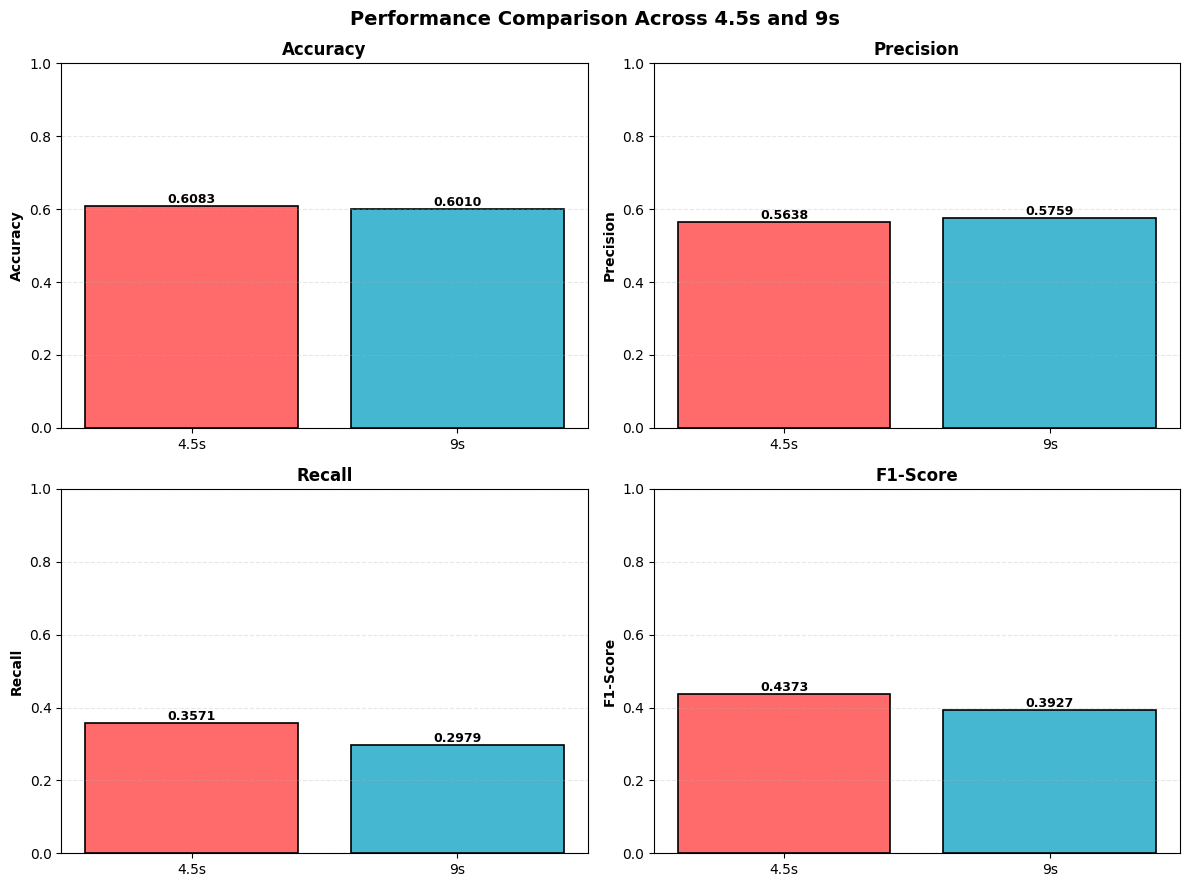

In [15]:
print("\n" + "="*70)
print("FINAL COMPARISON: 4.5s vs 9s")
print("="*70)

results_df = pd.DataFrame({
    "Window Size": ["4.5s", "9s"],
    "Accuracy": [window_size_results["4.5s"]["accuracy"], window_size_results["9s"]["accuracy"]],
    "Precision": [window_size_results["4.5s"]["precision"], window_size_results["9s"]["precision"]],
    "Recall": [window_size_results["4.5s"]["recall"], window_size_results["9s"]["recall"]],
    "F1-Score": [window_size_results["4.5s"]["f1"], window_size_results["9s"]["f1"]],
    "AUC-ROC": [window_size_results["4.5s"]["auc"], window_size_results["9s"]["auc"]],
    "Threshold": [window_size_results["4.5s"]["best_threshold"], window_size_results["9s"]["best_threshold"]]
})

print("\nDetailed performance summary:")
print(results_df.to_string(index=False))

best_variant = results_df.loc[results_df["F1-Score"].idxmax(), "Window Size"]
best_f1 = results_df["F1-Score"].max()
print(f"\nBest performing: {best_variant} with F1={best_f1:.4f}")

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle("Performance Comparison Across 4.5s and 9s", fontsize=14, fontweight="bold")

window_names = ["4.5s", "9s"]
metrics = ["accuracy", "precision", "recall", "f1"]
metric_labels = ["Accuracy", "Precision", "Recall", "F1-Score"]
colors = ["#FF6B6B", "#45B7D1"]

for idx, (metric, label) in enumerate(zip(metrics, metric_labels)):
    ax = axes[idx // 2, idx % 2]
    values = [window_size_results[w][metric] for w in window_names]
    bars = ax.bar(window_names, values, color=colors, edgecolor='black', linewidth=1.2)
    ax.set_ylabel(label, fontweight="bold")
    ax.set_ylim([0, 1])
    ax.grid(axis="y", alpha=0.3, linestyle='--')
    ax.set_title(label, fontweight="bold")
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                f"{val:.4f}", ha="center", va="bottom", fontweight="bold", fontsize=9)

plt.tight_layout()
plt.savefig("window_comparison_4.5s_9s.png", dpi=150, bbox_inches="tight")
print("\n✓ Comparison plot saved as 'window_comparison_4.5s_9s.png'")
plt.show()

## 14. Final Comparison: 4.5s vs 9s

Cell này so sánh hiệu suất giữa 2 cấu hình:
- Bảng tổng hợp metric (Accuracy, Precision, Recall, F1, AUC-ROC) cho cả 2 window
- Xác định cấu hình tốt nhất (dựa trên F1-Score)
- Vẽ biểu đồ bar so sánh 4 metric chính
- Lưu thành file `window_comparison_4.5s_9s.png`


DETAILED REPORT FOR BEST WINDOW (4.5s vs 9s)
Best variant: 4.5s

Classification Report:
              precision    recall  f1-score   support

  Normal (0)       0.62      0.79      0.70      1150
Abnormal (1)       0.56      0.36      0.44       854

    accuracy                           0.61      2004
   macro avg       0.59      0.58      0.57      2004
weighted avg       0.60      0.61      0.59      2004


Confusion Matrix Stats:
  TN: 914
  FP: 236
  FN: 549
  TP: 305

✓ Saved: confusion_matrix_best_4.5s.png


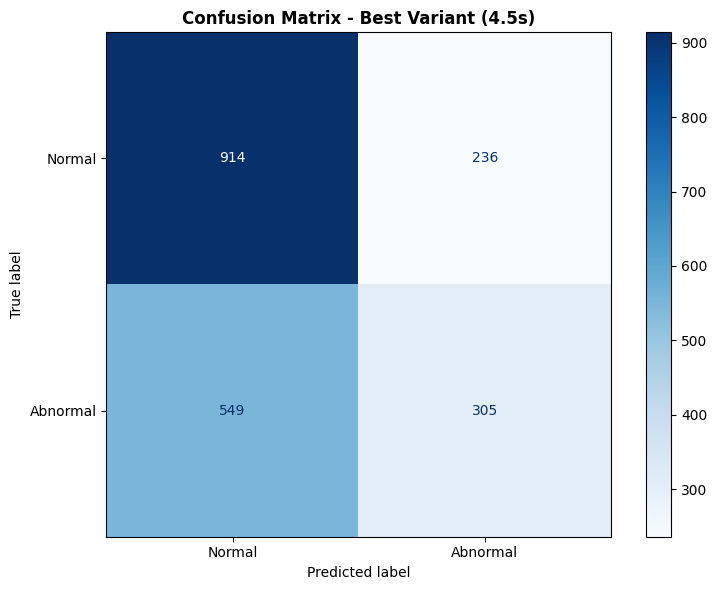

In [16]:
print("\n" + "="*70)
print("DETAILED REPORT FOR BEST WINDOW (4.5s vs 9s)")
print("="*70)

results_df = pd.DataFrame({
    "Window Size": ["4.5s", "9s"],
    "F1-Score": [window_size_results["4.5s"]["f1"], window_size_results["9s"]["f1"]]
})
best_variant = results_df.loc[results_df["F1-Score"].idxmax(), "Window Size"]

if best_variant == "4.5s":
    y_test_best = y_test_45
else:
    y_test_best = y_test_9s

y_pred_best = window_size_results[best_variant]["y_pred"]
cm_best = confusion_matrix(y_test_best, y_pred_best)
tn_best, fp_best, fn_best, tp_best = cm_best.ravel()

print(f"Best variant: {best_variant}")
print("\nClassification Report:")
print(classification_report(y_test_best, y_pred_best, target_names=["Normal (0)", "Abnormal (1)"], zero_division=0))

print("\nConfusion Matrix Stats:")
print(f"  TN: {tn_best}")
print(f"  FP: {fp_best}")
print(f"  FN: {fn_best}")
print(f"  TP: {tp_best}")

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_best, display_labels=["Normal", "Abnormal"] )
disp.plot(ax=ax, cmap="Blues", values_format="d")
ax.set_title(f"Confusion Matrix - Best Variant ({best_variant})", fontweight="bold")
plt.tight_layout()
plt.savefig(f"confusion_matrix_best_{best_variant}.png", dpi=150, bbox_inches="tight")
print(f"\n✓ Saved: confusion_matrix_best_{best_variant}.png")
plt.show()